---

# End-to-End Machine Learning Project

When training machine learning algorithms, it is important that we do not forget about the goal of the project and how will the algorithm be used in practice. The application will almost always drive the algorithm design and choices made during all steps in a machine learning systems. These include: data collection, model design, performance metrics, hyperparameter tuning, deployment and maintenance.

The main steps you will go through in this course and your projects are: 

1. Look at the big picture. 
2. Get the data. 
3. Discover and visualize the data to gain insights. 
4. Prepare the data for Machine Learning algorithms. 
5. Select a model and train it. 
6. Fine-tune your model. 
7. Present your solution. 
8. Launch, monitor, and maintain your system.

# California District's Median Housing Price

Your task is to use California census data to build a model of housing prices in the state. 

This data includes metrics such as the population, median income, and median housing price for each block group in California. Block groups are the smallest geographical unit for which the US Census Bureau publishes sample data (a block group typically has a population of 600 to 3,000 people). We will call them "districts" for short. 

Your model should learn from this data and be able to **predict the median housing price in any district, given all the other metrics**.

In [1]:
# Importing necessary libraries for data analysis and visualization
import numpy as np  # Provides support for numerical computations and working with arrays
import matplotlib.pyplot as plt  # Used for creating visualizations such as charts and graphs
%matplotlib inline  
# Ensures that plots are displayed directly within the Jupyter Notebook

# Setting a visualization style for plots to enhance readability and aesthetics
plt.style.use('bmh') # 'bmh' style offers a clean and professional look

import pandas as pd  # Provides data structures and functions for data manipulation and analysis

# Loading the housing dataset from the specified file path into a pandas DataFrame
housing = pd.read_csv('datasets\\housing.csv')

# Displaying the first few rows of the dataset to inspect its contents
housing


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## Data Visualization

The exploratory data analysis step preceding data cleaning and ML pipelines is extremely valuable in building insights and relationships amongst attributes and the dependent variable.

A histogram is a good choice for numerical attributes. It shows the number of instances (on the vertical axis) that have a given value range (on the horizontal axis). You can either plot this one attribute at a time, or you can call the ```hist()``` method on the whole dataset (as shown in the following code example), and it will plot a histogram for each numerical attribute:

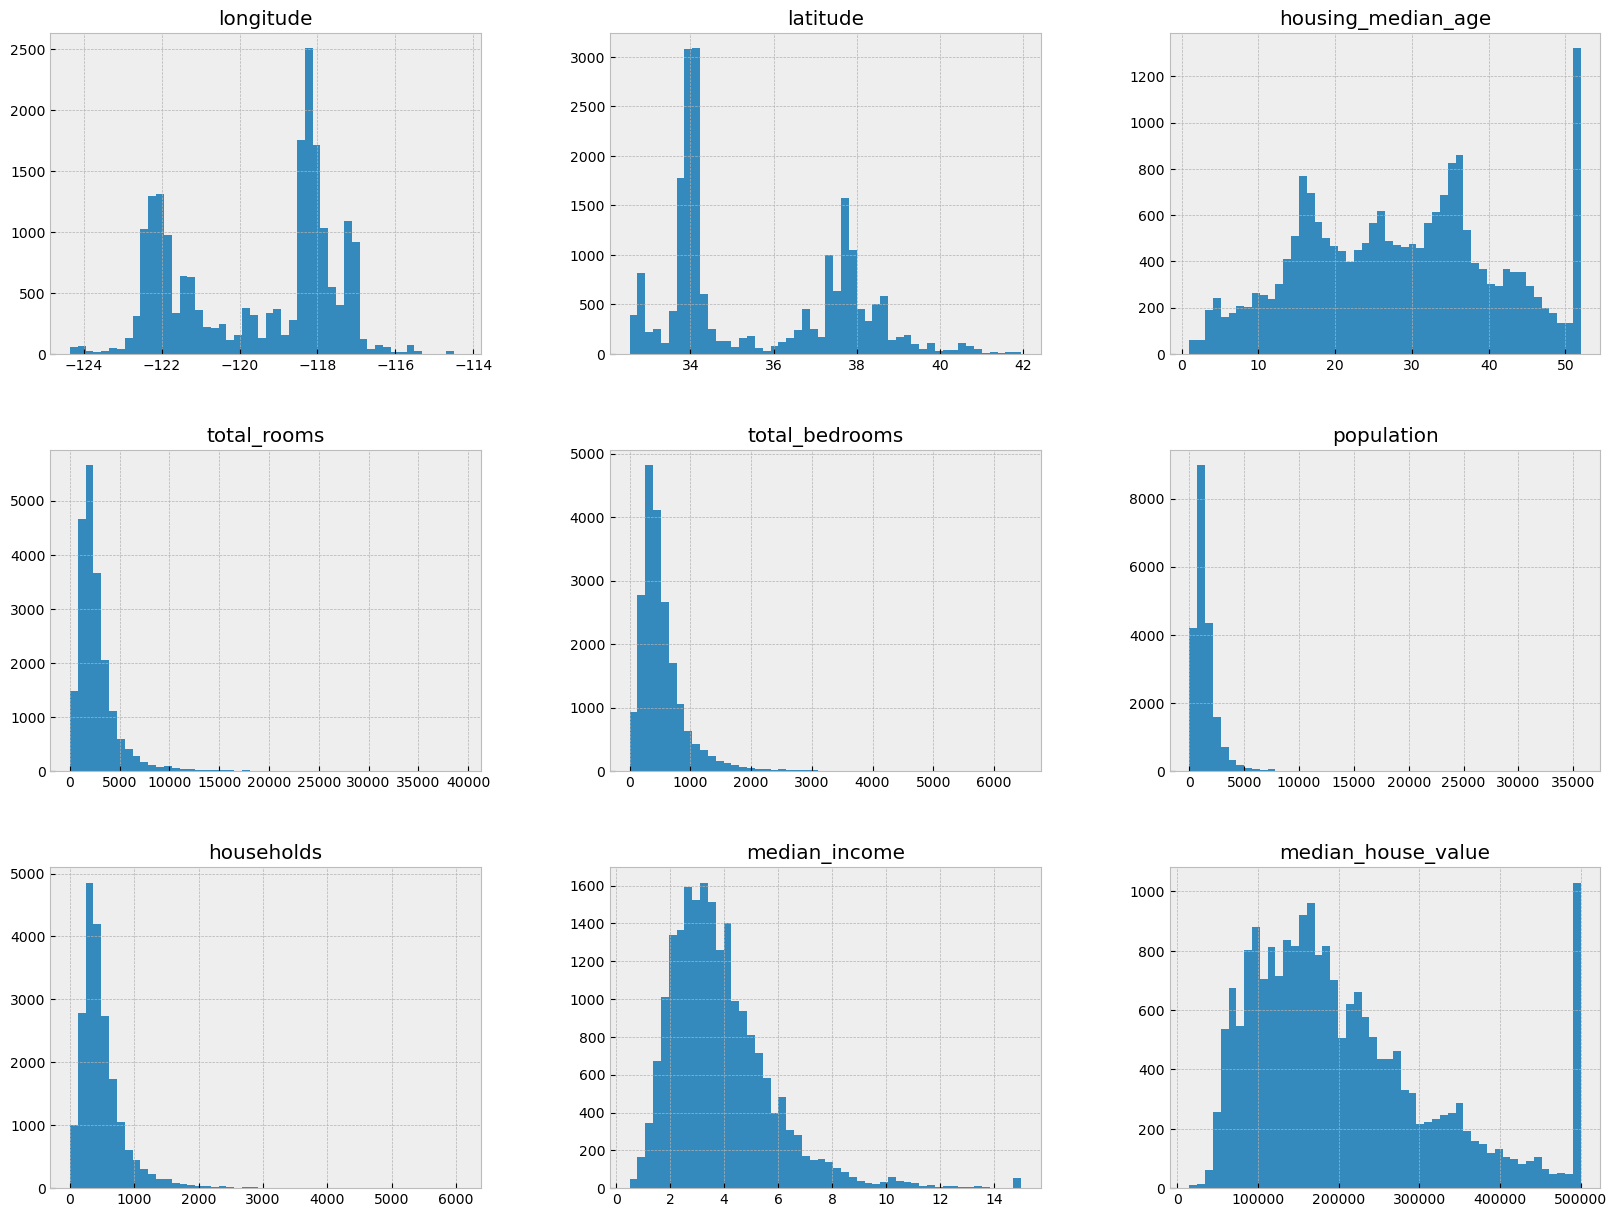

In [2]:
# Creating histograms for all numerical attributes in the housing dataset
# The 'bins=50' parameter divides the data into 50 intervals for better granularity
# The 'figsize=(20,15)' parameter sets the size of the figure to 20x15 inches for better readability
housing.hist(bins=50, figsize=(20,15));


Observations:

1. First, the ```median_income``` attribute does not look like it is expressed in US dollars (USD). After checking with the team that collected the data, you are told that the data has been scaled and capped at 15 (actually, 15.0001) for higher median incomes, and at 0.5 (actually, 0.4999) for lower median incomes. The numbers represent roughly tens of thousands of dollars (e.g., 3 actually means about $\$ 30,000$). Working with preprocessed attributes is common in Machine Learning, and it is not necessarily a problem, but you should try to understand how the data was computed.

2. The ```housing_median_age``` and the ```median_house_value``` were also capped. The latter may be a serious problem since it is your target attribute (your labels). Solutions include:
    1. Collect proper labels for the districts whose those labels were capped.
    2. Remove those districts from the training dataset. This will avoid biasing your system into *thinking* prices cannot go beyond $\$ 500,000$.
    
3. All attributes have very different scales.

4. Many attributes have tail-heavy distributions. This may pose a challenge and we will see later how to transform them close to bell-shaped distributions.

### Geographical Data

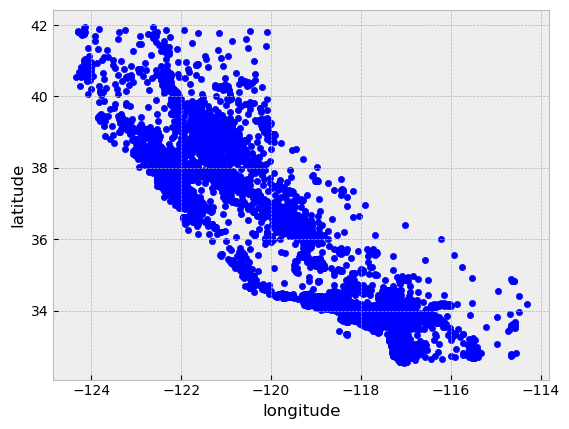

In [3]:
# Creating a scatter plot to visualize the geographical distribution of the housing data
# 'kind='scatter'' specifies that a scatter plot should be created
# 'x='longitude'' sets the x-axis to represent the longitude of the housing locations
# 'y='latitude'' sets the y-axis to represent the latitude of the housing locations
housing.plot(kind='scatter', x='longitude', y='latitude');


Although the plot looks like California, it doesn't make it justice when highlighting more dense areas. Let's modify the transparency of each point to help with that:

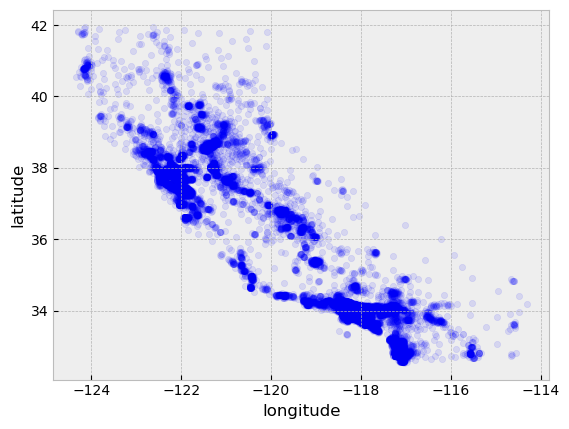

In [4]:
# Creating a scatter plot to visualize the geographical distribution of the housing data
# 'kind='scatter'' specifies that a scatter plot should be created
# 'x='longitude'' sets the x-axis to represent the longitude of the housing locations
# 'y='latitude'' sets the y-axis to represent the latitude of the housing locations
# 'alpha=0.1' controls the transparency of the points, making overlapping points more visible
housing.plot(kind='scatter', x='longitude', y='latitude', alpha=0.1);


Now that's much better: you can clearly see the high-density areas, namely the Bay Area and around Los Angeles and San Diego, plus a long line of fairly high density in the Central Valley, in particular around Sacramento and Fresno.

Now let's add housing prices.

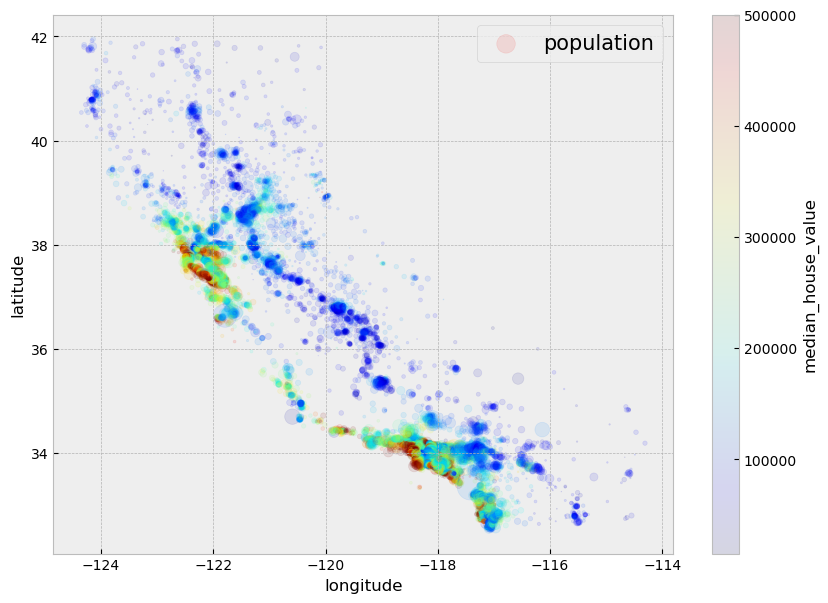

In [5]:
# Creating a scatter plot to visualize the geographical distribution of the housing data
housing.plot(kind='scatter', x='longitude', y='latitude', alpha=0.1,
             
             # 's' determines the size of each point based on the population column (scaled down by dividing by 100)
             s=housing['population']/100, 
             
             # 'label' provides a legend label for the population-based sizing of the points
             label='population',
             
             # 'figsize' sets the size of the figure to 10 inches by 7 inches for better readability
             figsize=(10,7),  
             
             # 'c' sets the color of the points based on the median house value, allowing for better data insights
             c='median_house_value', 
             
             # 'cmap' specifies the color map to use; 'jet' provides a wide range of colors for value differentiation
             cmap=plt.cm.jet, 
             
             # 'colorbar' adds a color bar to the plot, providing a reference for interpreting colors
             colorbar=True);

# Adding a legend to the plot with a specified font size for better visibility
plt.legend(fontsize=15);


### Correlations

We can compute the (linear) Pearson's correlation coefficient between pairs of attributes with the method ```corr()```:

In [6]:
# Calculating the correlation matrix for the numerical attributes in the housing dataset
# 'method='pearson'' specifies the use of Pearson correlation, which measures linear relationships
# 'numeric_only=True' ensures that only numerical columns are considered in the correlation calculation
corr_matrix = housing.corr(method='pearson', numeric_only=True)

# Displaying the correlation matrix to analyze relationships between different numerical features
corr_matrix


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


Let's check which attribute has the largest correlation with the dependent attributes (the labels):

In [7]:
# Extracting the correlation values of the 'median_house_value' column with all other numerical features
# Sorting the correlation values in descending order to identify the strongest positive correlations first
corr_matrix['median_house_value'].sort_values(ascending=False)


median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

Another way to check for function, ```scatter_matrix()``` correlation between attributes is to use the pandas which plots every numerical attribute against every other numerical attribute:

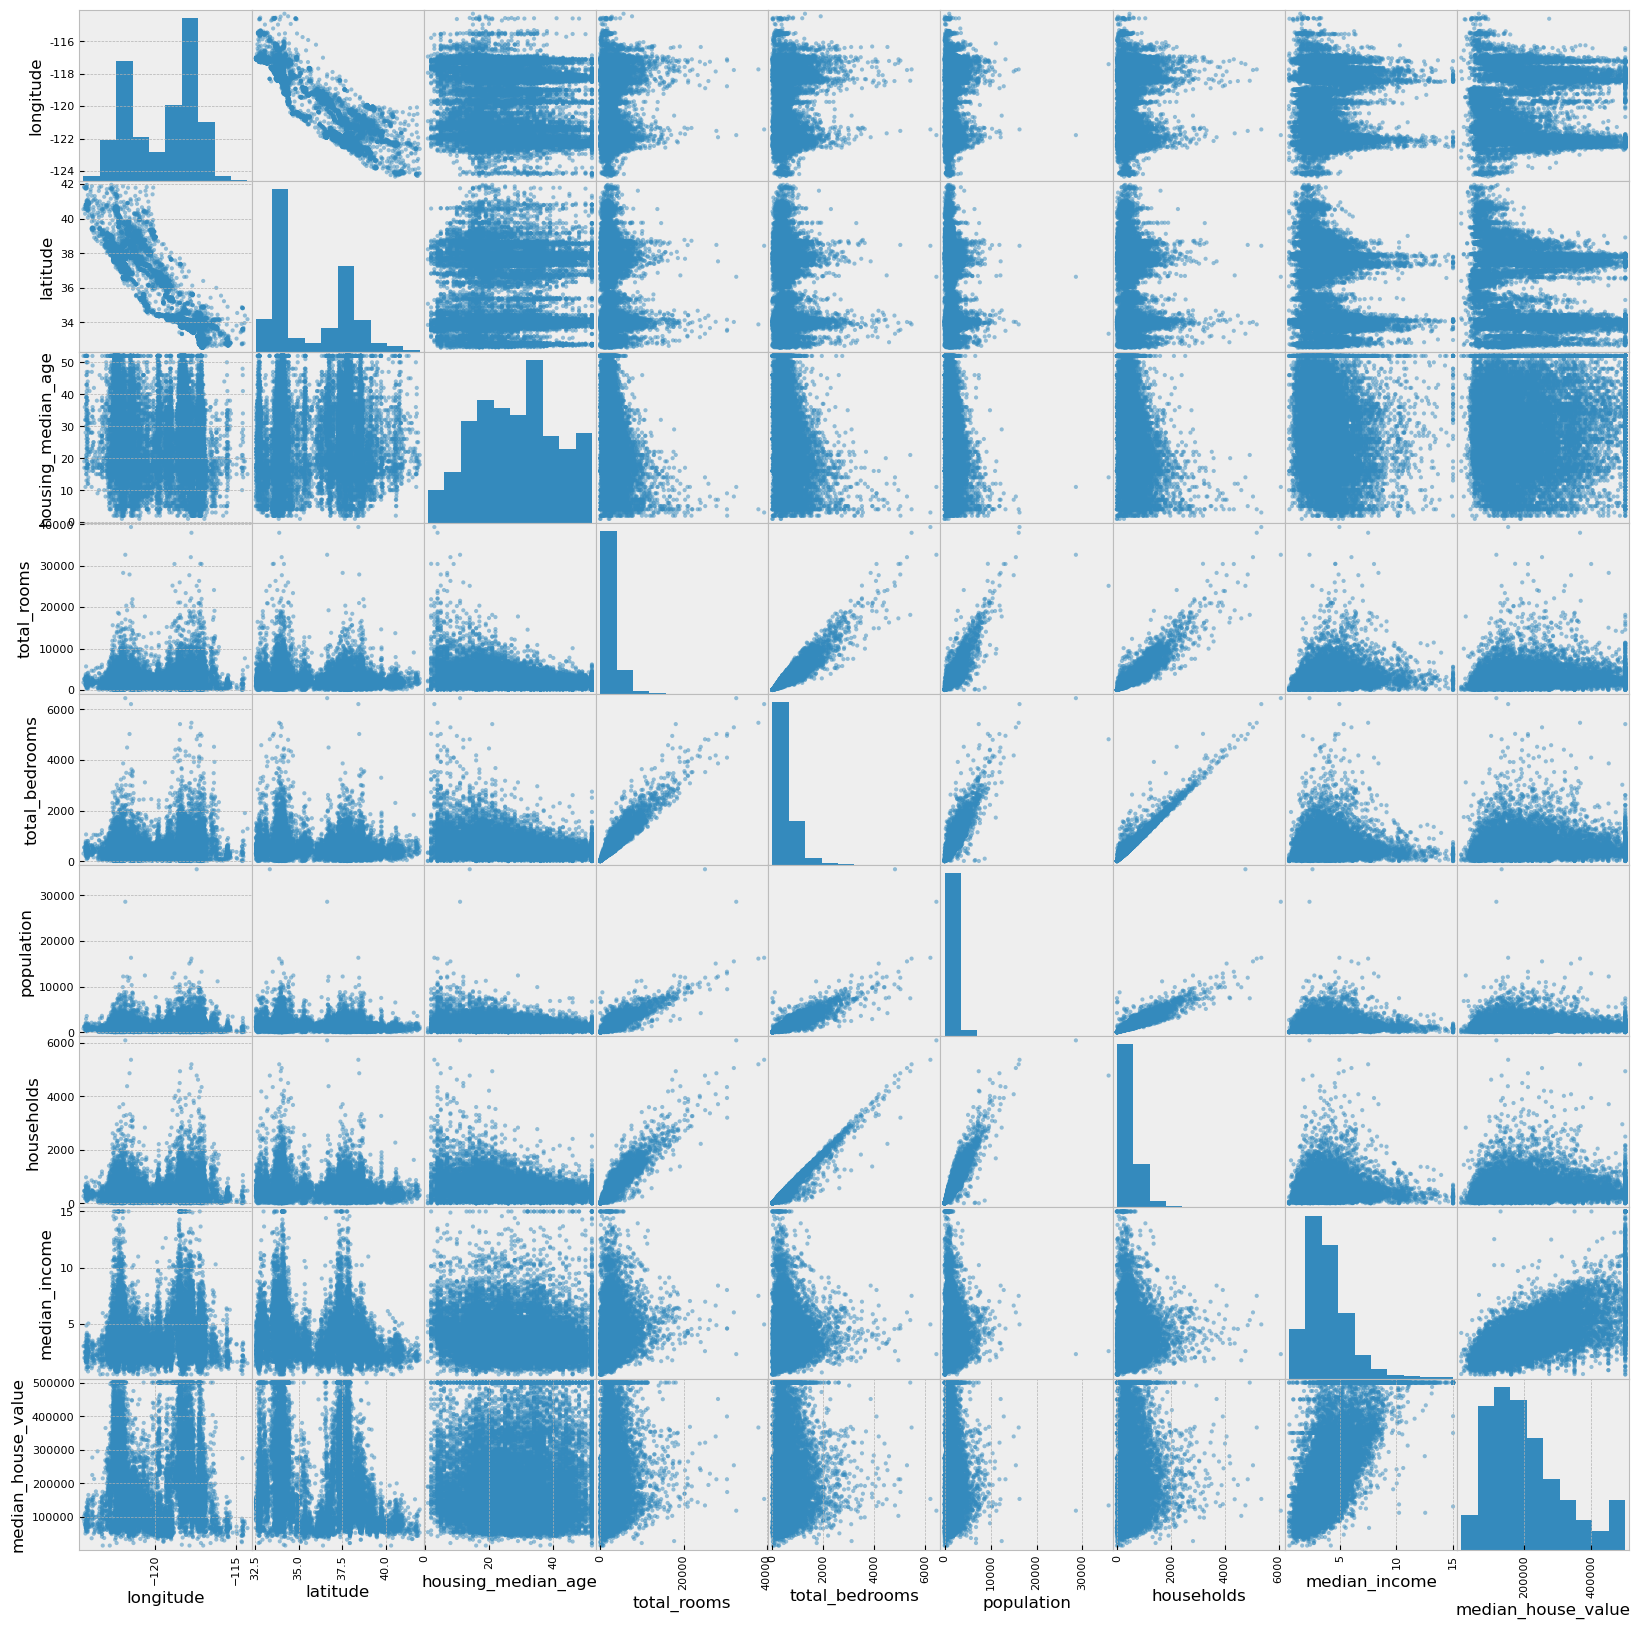

In [8]:
# Importing the scatter_matrix function from pandas to visualize pairwise relationships between numerical features
from pandas.plotting import scatter_matrix

# Creating a scatter plot matrix for all numerical attributes in the housing dataset
# 'figsize=(20,20)' sets the size of the figure to 20x20 inches for better readability of the plots
scatter_matrix(housing, figsize=(20,20));


The most promising attribute to predict the median house value is the ```median_income```, so let's zoom in on their correlation scatterplot.

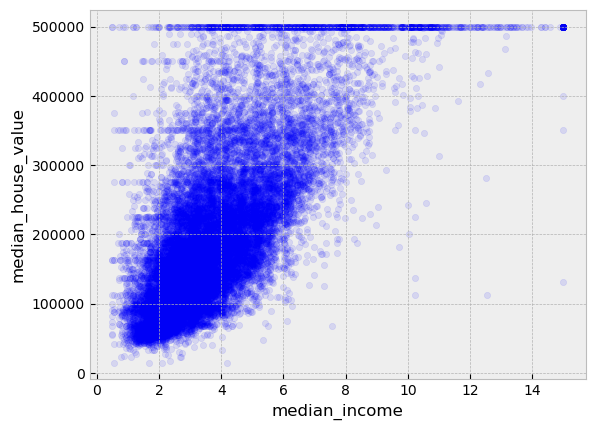

In [9]:
# Creating a scatter plot to visualize the relationship between median income and median house value
housing.plot(kind='scatter', 
             
             # 'x' specifies the median income as the variable for the x-axis
             x='median_income',  
             
             # 'y' specifies the median house value as the variable for the y-axis
             y='median_house_value',  
             
             # 'alpha=0.1' controls the transparency of the points, helping to visualize data density and overlap
             alpha=0.1);


Instead of working with ```pandas``` datframes, you can cast it first to a ```numpy``` array and then use appropriate indexing to access the corresponding column:

In [10]:
# Converting the housing DataFrame to a NumPy array for numerical computations and efficient processing
housing_np = housing.to_numpy()

# Displaying the shape of the resulting NumPy array
# The shape provides the number of rows and columns in the dataset (rows, columns)
housing_np.shape


(20640, 10)

In [11]:
# Displaying the contents of the NumPy array converted from the housing DataFrame
# This will output the entire dataset in array format, where each row represents a data instance 
# and each column corresponds to a feature from the original DataFrame
housing_np


array([[-122.23, 37.88, 41.0, ..., 8.3252, 452600.0, 'NEAR BAY'],
       [-122.22, 37.86, 21.0, ..., 8.3014, 358500.0, 'NEAR BAY'],
       [-122.24, 37.85, 52.0, ..., 7.2574, 352100.0, 'NEAR BAY'],
       ...,
       [-121.22, 39.43, 17.0, ..., 1.7, 92300.0, 'INLAND'],
       [-121.32, 39.43, 18.0, ..., 1.8672, 84700.0, 'INLAND'],
       [-121.24, 39.37, 16.0, ..., 2.3886, 89400.0, 'INLAND']],
      dtype=object)

In [12]:
# Displaying the column names of the housing DataFrame
# This provides an overview of the available features in the dataset
housing.columns


Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

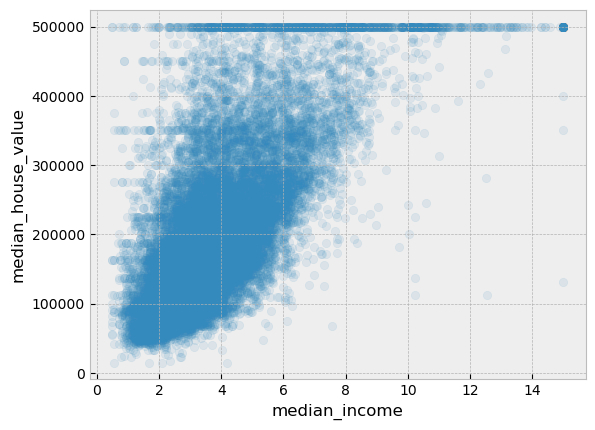

In [13]:
# Creating a scatter plot to visualize the relationship between median income and median house value
# 'housing_np[:,-3]' selects the third-to-last column (median_income) for the x-axis
# 'housing_np[:,-2]' selects the second-to-last column (median_house_value) for the y-axis
# 'alpha=0.1' sets the transparency of the points to avoid overplotting and visualize density better
plt.scatter(housing_np[:,-3], housing_np[:,-2], alpha=0.1)

# Labeling the x-axis to indicate it represents median income values
plt.xlabel('median_income')

# Labeling the y-axis to indicate it represents median house value
plt.ylabel('median_house_value');


## Attribute Combination

One last thing you may want to do before preparing the data for Machine Learning algorithms is to try out various attribute combinations. For example, the total number of rooms in a district is not very useful if you don't know how many households there are. What you really want is the number of rooms per household. Similarly, the total number of bedrooms by itself is not very useful: you probably want to compare it to the number of rooms. And the population per household also seems like an interesting attribute combination to look at. Let's create these new attributes:

In [14]:
# Creating a new feature to represent the average number of rooms per household
# Calculated by dividing the total number of rooms by the number of households
housing['rooms_per_household'] = housing['total_rooms'] / housing['households']

# Creating a new feature to represent the proportion of bedrooms to total rooms
# This provides insight into the housing structure and potential overcrowding
housing['bedrooms_per_room'] = housing['total_bedrooms'] / housing['total_rooms']

# Creating a new feature to represent the population per household
# This metric gives an idea of the average household size in the dataset
housing['population_per_household'] = housing['population'] / housing['households']

# Displaying the updated DataFrame with the new calculated features
housing


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,5.045455,0.224625,2.560606
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,6.114035,0.215208,3.122807
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,5.205543,0.215173,2.325635
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,5.329513,0.219892,2.123209


Now let's look at the correlation matrix again:

In [15]:
# Calculating the correlation matrix for all numerical attributes in the housing dataset
# 'method='pearson'' specifies the use of Pearson correlation, which measures the linear relationship between variables
# 'numeric_only=True' ensures that only numerical columns are considered in the correlation calculation
corr_matrix = housing.corr(method='pearson', numeric_only=True)

# Extracting and sorting the correlation values of the 'median_house_value' column
# Sorting in descending order to identify the features most strongly correlated with house value
corr_matrix['median_house_value'].sort_values(ascending=False)


median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64

Observations:
    
1. The new feature ```bedrooms_per_room``` is much more correlated with the median house value than the total number of rooms or bedrooms. Since the correlation is negative, this means that houses with a lower bedroom/room ratio tend to be more expensive.

2. The number of rooms per household is also more informative than the total number of rooms - obviously, the larger the houses, the more expensive they are.

---